# Arousal Prediction — v4 Pipeline (Fixed)

## Fixes applied vs v4

| v4 bug | Fix |
|--------|-----|
| Feature selection RF trained on full train (all val pids see their own labels) | Feature selection moved **inside** LOPO fold |
| Outlier removal (IsolationForest) fitted on full train | IsolationForest fitted on train fold only |
| Per-pid z-score uses val pid's own rows | Val pid normalised using **train-fold** global mean/std |
| `*_count` features dominate importance (proxy for session/pid, not physiology) | Count features **excluded** |
| Class weights / ADASYN computed on full train, reused per fold | Recomputed fresh inside each fold |

> **What to expect**: LOPO MAE will increase after these fixes — that is correct.  
> The v4 LOPO of 0.80 was optimistic due to the leaks above.


## 0. Install & imports

In [1]:
!pip install pandas numpy scipy scikit-learn lightgbm imbalanced-learn matplotlib -q


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import welch
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
from imblearn.over_sampling import ADASYN, SMOTE
import matplotlib.pyplot as plt

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [3]:
DATA = '.'

train_labels = pd.read_csv(f'{DATA}/train-label.csv')
test_labels  = pd.read_csv(f'{DATA}/test-label.csv')

trainbvp   = pd.read_csv(f'{DATA}/train-bvp.csv')
traineda   = pd.read_csv(f'{DATA}/train-eda.csv')
traintemp  = pd.read_csv(f'{DATA}/train-temp.csv')
trainhr    = pd.read_csv(f'{DATA}/train-hr.csv')
trainibi   = pd.read_csv(f'{DATA}/train-ibi.csv')
trainbrain = pd.read_csv(f'{DATA}/train-brain.csv')
trainacc   = pd.read_csv(f'{DATA}/train-acc.csv')

testbvp    = pd.read_csv(f'{DATA}/test-bvp.csv')
testeda    = pd.read_csv(f'{DATA}/test-eda.csv')
testtemp   = pd.read_csv(f'{DATA}/test-temp.csv')
testhr     = pd.read_csv(f'{DATA}/test-hr.csv')
testibi    = pd.read_csv(f'{DATA}/test-ibi.csv')
testbrain  = pd.read_csv(f'{DATA}/test-brain.csv')
testacc    = pd.read_csv(f'{DATA}/test-acc.csv')

print(f'Train: {len(train_labels)} | Test: {len(test_labels)}')
print(train_labels['arousal'].value_counts().sort_index())

Train: 1456 | Test: 1496
arousal
1     55
2    430
3    554
4    345
5     72
Name: count, dtype: int64


## 2. Feature Helpers

In [4]:
WINDOW       = 5000
BVP_WINDOW   = 10000
BRAIN_WINDOW = 10000
IBI_WINDOW   = 20000
BASELINE_W   = 30000   # 30 s lookback for delta features


def assign_windows_forward(sensor_df, labels_df, window):
    results = []
    for pid in labels_df['pid'].unique():
        lbl = labels_df[labels_df['pid'] == pid].sort_values('timestamp')
        sen = sensor_df[sensor_df['pid'] == pid].copy()
        if len(sen) == 0:
            continue
        lbl_ts = lbl['timestamp'].values
        bins   = np.append(lbl_ts, lbl_ts[-1] + window)
        sen['label_ts'] = pd.cut(sen['timestamp'], bins=bins,
                                  labels=lbl_ts, right=False, include_lowest=True)
        results.append(sen.dropna(subset=['label_ts']))
    if not results:
        return pd.DataFrame()
    out = pd.concat(results, ignore_index=True)
    out['label_ts'] = out['label_ts'].astype(np.int64)
    return out


def assign_windows_lookback(sensor_df, labels_df, window):
    results = []
    for pid in labels_df['pid'].unique():
        lbl = labels_df[labels_df['pid'] == pid].sort_values('timestamp')
        sen = sensor_df[sensor_df['pid'] == pid].copy()
        if len(sen) == 0:
            continue
        for ts in lbl['timestamp'].values:
            chunk = sen[(sen['timestamp'] >= ts - window) & (sen['timestamp'] < ts)]
            if len(chunk) > 0:
                chunk = chunk.copy()
                chunk['label_ts'] = ts
                chunk['pid']      = pid
                results.append(chunk)
    if not results:
        return pd.DataFrame()
    out = pd.concat(results, ignore_index=True)
    out['label_ts'] = out['label_ts'].astype(np.int64)
    return out


def safe_stats(vals, prefix):
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return {f'{prefix}_{k}': np.nan
                for k in ['mean','std','min','max','range','q25','q75','iqr','skew','kurt','rms']}
    return {
        f'{prefix}_mean':  float(np.mean(a)),
        f'{prefix}_std':   float(np.std(a)) if len(a) > 1 else 0.0,
        f'{prefix}_min':   float(np.min(a)),
        f'{prefix}_max':   float(np.max(a)),
        f'{prefix}_range': float(np.ptp(a)),
        f'{prefix}_q25':   float(np.percentile(a, 25)),
        f'{prefix}_q75':   float(np.percentile(a, 75)),
        f'{prefix}_iqr':   float(np.percentile(a, 75) - np.percentile(a, 25)),
        f'{prefix}_skew':  float(stats.skew(a))     if len(a) > 2 else 0.0,
        f'{prefix}_kurt':  float(stats.kurtosis(a)) if len(a) > 2 else 0.0,
        f'{prefix}_rms':   float(np.sqrt(np.mean(a ** 2))),
    }


def spectral_features(vals, fs, prefix):
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) < 8:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}
    try:
        f, psd = welch(a, fs=fs, nperseg=min(len(a), 64))
        lf = np.trapz(psd[(f >= 0.04) & (f <= 0.15)], f[(f >= 0.04) & (f <= 0.15)])
        hf = np.trapz(psd[(f >= 0.15) & (f <= 0.40)], f[(f >= 0.15) & (f <= 0.40)])
        return {f'{prefix}_lf': float(lf), f'{prefix}_hf': float(hf),
                f'{prefix}_lf_hf': float(lf / (hf + 1e-9))}
    except Exception:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}


print('Helpers defined.')

Helpers defined.


## 3. Feature Extraction

In [5]:
def build_features(labels_df, bvp_df, eda_df, temp_df, hr_df,
                    ibi_df, brain_df, acc_df):

    print('  Forward windows...')
    bvp_w   = assign_windows_forward(bvp_df,   labels_df, BVP_WINDOW)
    eda_w   = assign_windows_forward(eda_df,   labels_df, WINDOW)
    temp_w  = assign_windows_forward(temp_df,  labels_df, WINDOW)
    hr_w    = assign_windows_forward(hr_df,    labels_df, WINDOW)
    ibi_w   = assign_windows_forward(ibi_df,   labels_df, IBI_WINDOW)
    brain_w = assign_windows_forward(brain_df, labels_df, BRAIN_WINDOW)
    acc_w   = assign_windows_forward(acc_df,   labels_df, WINDOW)

    print('  Lookback baseline windows (30 s)...')
    eda_b  = assign_windows_lookback(eda_df,  labels_df, BASELINE_W)
    temp_b = assign_windows_lookback(temp_df, labels_df, BASELINE_W)
    hr_b   = assign_windows_lookback(hr_df,   labels_df, BASELINE_W)
    acc_b  = assign_windows_lookback(acc_df,  labels_df, BASELINE_W)

    # BVP
    print('  BVP...')
    bvp_agg = bvp_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    bvp_feats = []
    for _, r in bvp_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'bvp'))
        d.update(spectral_features(r['value'], fs=64, prefix='bvp_spec'))
        a = np.array(r['value'])
        d['bvp_zcr'] = float(np.sum(np.diff(np.sign(np.diff(a))) != 0) / max(len(a), 1))
        bvp_feats.append(d)
    bvp_feat_df = pd.DataFrame(bvp_feats)

    # EDA + delta
    print('  EDA...')
    eda_agg    = eda_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    eda_b_mean = eda_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    eda_b_mean.columns = ['pid','label_ts','eda_baseline']
    eda_feats = []
    for _, r in eda_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'eda'))
        a = np.array(r['value'], dtype=float)
        if len(a) > 2:
            d['eda_slope'] = float(np.polyfit(np.arange(len(a)), a, 1)[0])
            d['eda_peaks'] = float(np.sum((np.diff(np.sign(np.diff(a)))) < 0))
        else:
            d['eda_slope'] = np.nan; d['eda_peaks'] = np.nan
        eda_feats.append(d)
    eda_feat_df = pd.DataFrame(eda_feats)
    eda_feat_df = eda_feat_df.merge(eda_b_mean, on=['pid','label_ts'], how='left')
    eda_feat_df['eda_delta'] = eda_feat_df['eda_mean'] - eda_feat_df['eda_baseline']

    # TEMP + delta
    print('  TEMP...')
    temp_feat_df = temp_w.groupby(['pid','label_ts'])['value'].agg(
        temp_mean='mean', temp_std='std', temp_min='min',
        temp_max='max', temp_range=lambda x: x.max() - x.min()
    ).reset_index()
    temp_b_mean = temp_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    temp_b_mean.columns = ['pid','label_ts','temp_baseline']
    temp_feat_df = temp_feat_df.merge(temp_b_mean, on=['pid','label_ts'], how='left')
    temp_feat_df['temp_delta'] = temp_feat_df['temp_mean'] - temp_feat_df['temp_baseline']

    # HR + delta
    print('  HR...')
    hr_feat_df = hr_w.groupby(['pid','label_ts'])['value'].agg(
        hr_mean='mean', hr_std='std', hr_min='min',
        hr_max='max', hr_range=lambda x: x.max() - x.min()
    ).reset_index()
    hr_b_mean = hr_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    hr_b_mean.columns = ['pid','label_ts','hr_baseline']
    hr_feat_df = hr_feat_df.merge(hr_b_mean, on=['pid','label_ts'], how='left')
    hr_feat_df['hr_delta'] = hr_feat_df['hr_mean'] - hr_feat_df['hr_baseline']

    # IBI + HRV
    print('  IBI/HRV...')
    ibi_agg = ibi_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    ibi_feats = []
    for _, r in ibi_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'ibi'))
        a = np.array(r['value'], dtype=float)
        a = a[~np.isnan(a)]
        if len(a) > 1:
            diffs = np.diff(a)
            d['ibi_rmssd'] = float(np.sqrt(np.mean(diffs ** 2)))
            d['ibi_sdnn']  = float(np.std(a))
            d['ibi_pnn50'] = float(np.mean(np.abs(diffs) > 50))
        else:
            d['ibi_rmssd'] = np.nan; d['ibi_sdnn'] = np.nan; d['ibi_pnn50'] = np.nan
        d.update(spectral_features(r['value'], fs=4, prefix='ibi_spec'))
        ibi_feats.append(d)
    ibi_feat_df = pd.DataFrame(ibi_feats)

    # Brain
    print('  Brain...')
    brain_cols = ['delta','lowAlpha','highAlpha','lowBeta','highBeta','lowGamma','theta']
    brain_agg  = brain_w.groupby(['pid','label_ts'])[brain_cols].agg(['mean','std']).reset_index()
    brain_agg.columns = ['pid','label_ts'] + [f'brain_{c}_{s}' for c in brain_cols for s in ['mean','std']]
    brain_agg['brain_alpha_beta']  = (
        (brain_agg['brain_lowAlpha_mean'] + brain_agg['brain_highAlpha_mean']) /
        (brain_agg['brain_lowBeta_mean']  + brain_agg['brain_highBeta_mean'] + 1e-9))
    brain_agg['brain_theta_alpha'] = (
        brain_agg['brain_theta_mean'] /
        (brain_agg['brain_lowAlpha_mean'] + brain_agg['brain_highAlpha_mean'] + 1e-9))
    brain_agg['brain_engagement']  = (
        brain_agg['brain_lowBeta_mean'] /
        (brain_agg['brain_theta_mean'] + brain_agg['brain_lowAlpha_mean'] + 1e-9))

    # ACC + delta
    print('  ACC...')
    acc_w['mag'] = np.sqrt(acc_w['x']**2 + acc_w['y']**2 + acc_w['z']**2)
    acc_b['mag'] = np.sqrt(acc_b['x']**2 + acc_b['y']**2 + acc_b['z']**2)
    acc_agg   = acc_w.groupby(['pid','label_ts'])['mag'].apply(list).reset_index()
    acc_b_mean = acc_b.groupby(['pid','label_ts'])['mag'].mean().reset_index()
    acc_b_mean.columns = ['pid','label_ts','acc_baseline']
    acc_feats = []
    for _, r in acc_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['mag'], 'acc'))
        a = np.array(r['mag'], dtype=float)
        if len(a) > 2:
            jerk = np.diff(a)
            d['acc_jerk_mean'] = float(np.mean(np.abs(jerk)))
            d['acc_jerk_std']  = float(np.std(jerk))
        else:
            d['acc_jerk_mean'] = np.nan; d['acc_jerk_std'] = np.nan
        acc_feats.append(d)
    acc_feat_df = pd.DataFrame(acc_feats)
    acc_feat_df = acc_feat_df.merge(acc_b_mean, on=['pid','label_ts'], how='left')
    acc_feat_df['acc_delta'] = acc_feat_df['acc_mean'] - acc_feat_df['acc_baseline']

    # Merge everything
    print('  Merging...')
    base = labels_df[['id','pid','timestamp']].copy()
    base['label_ts'] = base['timestamp']
    merged = base
    for fdf in [bvp_feat_df, eda_feat_df, temp_feat_df, hr_feat_df,
                ibi_feat_df, brain_agg, acc_feat_df]:
        fdf['label_ts'] = fdf['label_ts'].astype(np.int64)
        merged = merged.merge(fdf, on=['pid','label_ts'], how='left')
    return merged.drop(columns=['label_ts'])


print('build_features() defined.')

build_features() defined.


In [6]:
print('Extracting TRAIN features (~4-6 min)...')
train_feats = build_features(train_labels, trainbvp, traineda, traintemp,
                              trainhr, trainibi, trainbrain, trainacc)
print(f'Train: {train_feats.shape}, missing: {train_feats.isnull().mean().mean():.2%}')

Extracting TRAIN features (~4-6 min)...
  Forward windows...
  Lookback baseline windows (30 s)...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI/HRV...
  Brain...
  ACC...
  Merging...
Train: (1456, 96), missing: 19.41%


In [7]:
print('Extracting TEST features (~4-6 min)...')
test_feats = build_features(test_labels, testbvp, testeda, testtemp,
                             testhr, testibi, testbrain, testacc)
print(f'Test: {test_feats.shape}, missing: {test_feats.isnull().mean().mean():.2%}')

Extracting TEST features (~4-6 min)...
  Forward windows...
  Lookback baseline windows (30 s)...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI/HRV...
  Brain...
  ACC...
  Merging...
Test: (1496, 96), missing: 19.99%


## 4. Lag Features (within-pid — no cross-pid leak)

In [8]:
LAG_COLS = [
    'eda_mean','eda_min','eda_q75','eda_slope','eda_delta',
    'temp_mean','temp_min','temp_delta',
    'hr_mean','hr_std','hr_delta',
    'bvp_mean','bvp_skew',
    'acc_mean','acc_max','acc_delta',
    'ibi_rmssd','ibi_sdnn',
]


def add_lag_features(feat_df, lag_cols, lags=(1, 2)):
    parts = []
    for pid in feat_df['pid'].unique():
        sub = feat_df[feat_df['pid'] == pid].sort_values('timestamp').copy()
        for lag in lags:
            for col in lag_cols:
                if col in sub.columns:
                    sub[f'{col}_lag{lag}'] = sub[col].shift(lag)
        parts.append(sub)
    return pd.concat(parts).sort_values('id').reset_index(drop=True)


print('Adding lag features to train...')
train_w_lags = add_lag_features(train_feats, LAG_COLS)
print('Adding lag features to test...')
test_w_lags  = add_lag_features(test_feats,  LAG_COLS)

new_cols = [f'{c}_lag{l}' for c in LAG_COLS for l in [1, 2]]
print(f'Added {len(new_cols)} lag columns. Train shape: {train_w_lags.shape}')

Adding lag features to train...
Adding lag features to test...
Added 36 lag columns. Train shape: (1456, 132)


## 5. Prepare Base DataFrame

**Key fix:** `*_count` features are removed here.  
They measure window coverage (how many sensor readings fell in the window),  
not physiology. In v4 they dominated feature importance at ~6% each,  
meaning the model was partly predicting arousal from data-quality proxies.


In [9]:
# Merge labels onto train
train_base_raw = train_w_lags.merge(train_labels[['id','arousal']], on='id', how='left')
test_df_raw    = test_w_lags.copy()

# All feature columns (before filtering)
all_cols = [c for c in train_base_raw.columns if c not in ['id','pid','timestamp','arousal']]

# ── FIX 1: Remove *_count features ──────────────────────────────────────────
count_cols = [c for c in all_cols if c.endswith('_count')]
print(f'Removing {len(count_cols)} count features: {count_cols}')
feat_cols_base = [c for c in all_cols if not c.endswith('_count')]

# ── Missing indicators (per sensor group) ────────────────────────────────────
sensor_groups = {
    'bvp':   [c for c in feat_cols_base if c.startswith('bvp')],
    'eda':   [c for c in feat_cols_base if c.startswith('eda')],
    'temp':  [c for c in feat_cols_base if c.startswith('temp')],
    'hr':    [c for c in feat_cols_base if c.startswith('hr')],
    'ibi':   [c for c in feat_cols_base if c.startswith('ibi')],
    'brain': [c for c in feat_cols_base if c.startswith('brain')],
    'acc':   [c for c in feat_cols_base if c.startswith('acc')],
}
indicator_cols = []
for grp, cols in sensor_groups.items():
    if cols:
        ind = f'{grp}_missing'
        train_base_raw[ind] = train_base_raw[cols].isnull().any(axis=1).astype(int)
        test_df_raw[ind]    = test_df_raw[cols].isnull().any(axis=1).astype(int)
        indicator_cols.append(ind)

feat_cols_base = feat_cols_base + indicator_cols

# ── Basic imputation (pid median → global median) ────────────────────────────
# This is a mild leak (uses all pids for global fallback), but unavoidable
# without making every fold's imputation independent (very expensive).
def impute_by_pid(df, cols):
    df = df.copy()
    df[cols] = df[cols].fillna(df.groupby('pid')[cols].transform('median'))
    df[cols] = df[cols].fillna(df[cols].median())
    return df

train_base = impute_by_pid(train_base_raw, feat_cols_base)
test_df    = impute_by_pid(test_df_raw,    feat_cols_base)
# Any test NaN not covered by test medians → use train medians
test_df[feat_cols_base] = test_df[feat_cols_base].fillna(
    train_base[feat_cols_base].median())

print(f'Feature count (count cols removed): {len(feat_cols_base)}')
print(f'Train NaN remaining: {train_base[feat_cols_base].isnull().sum().sum()}')
print(f'Test  NaN remaining: {test_df[feat_cols_base].isnull().sum().sum()}')
print(f'Train shape: {train_base.shape}')

Removing 0 count features: []
Feature count (count cols removed): 136
Train NaN remaining: 8736
Test  NaN remaining: 8976
Train shape: (1456, 140)


## 6. Model Hyperparameters & Helpers

In [10]:
def ordinal_clip(pred):
    return np.clip(np.round(pred), 1, 5).astype(int)


rf_params = dict(
    n_estimators=500, max_depth=10, min_samples_leaf=4,
    min_samples_split=8, max_features='sqrt', max_samples=0.8,
    random_state=42, n_jobs=-1,
)

lgb_params = dict(
    objective='regression_l1', metric='mae',
    n_estimators=400, learning_rate=0.04, num_leaves=31, max_depth=5,
    min_child_samples=20, subsample=0.75, colsample_bytree=0.75,
    reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbose=-1,
)

N_KEEP = 60   # features to keep per fold

print('Params defined.')

Params defined.


## 7. Fixed Leave-One-Pid-Out CV

All leaky steps (outlier removal, normalisation, feature selection, ADASYN)  
are **recomputed from scratch inside each fold** using only the training pids.

The validation pid is normalised with training-fold statistics — it contributes  
no information to any fitting step.


In [11]:
pids = train_base['pid'].unique()
lopo_maes       = {'rf': [], 'lgb': [], 'ens': []}
lopo_pid_results = []

print(f'LOPO CV ({len(pids)} folds) — all preprocessing inside each fold\n')

for held_pid in pids:
    mask_val = train_base['pid'] == held_pid
    mask_tr  = ~mask_val

    tr_df  = train_base[mask_tr].copy().reset_index(drop=True)
    val_df = train_base[mask_val].copy().reset_index(drop=True)

    # ── FIX 2: Outlier removal — fitted on train fold only ───────────────────
    X_tr_raw = tr_df[feat_cols_base].values
    y_tr_raw = tr_df['arousal'].values.astype(float)

    outlier_mask = np.zeros(len(tr_df), dtype=bool)
    for cls in np.unique(y_tr_raw):
        idx           = np.where(y_tr_raw == cls)[0]
        contamination = 0.05 if len(idx) < 100 else 0.07
        iso           = IsolationForest(n_estimators=100,
                                        contamination=contamination,
                                        random_state=42)
        preds         = iso.fit_predict(X_tr_raw[idx])
        outlier_mask[idx[preds == -1]] = True
    tr_df = tr_df[~outlier_mask].reset_index(drop=True)

    # ── FIX 3: Per-pid normalisation — val pid uses train-fold stats ─────────
    norm_cols = [c for c in feat_cols_base if not c.endswith('_missing')]

    # Normalise each training pid with its own mean/std
    tr_norm = tr_df.copy()
    for pid in tr_norm['pid'].unique():
        m   = tr_norm['pid'] == pid
        sub = tr_norm.loc[m, norm_cols]
        mu  = sub.mean()
        sig = sub.std().replace(0, np.nan)
        tr_norm.loc[m, norm_cols] = (sub - mu) / sig
    tr_norm[norm_cols] = tr_norm[norm_cols].fillna(0)

    # Normalise val pid using train-fold global mean/std (no val data used)
    mu_global  = tr_df[norm_cols].mean()
    sig_global = tr_df[norm_cols].std().replace(0, np.nan)
    val_norm   = val_df.copy()
    val_norm[norm_cols] = (val_df[norm_cols] - mu_global) / sig_global
    val_norm[norm_cols] = val_norm[norm_cols].fillna(0)

    # ── FIX 4: Feature selection — RF fitted on train fold only ──────────────
    X_sel = tr_norm[feat_cols_base].values
    y_sel = tr_norm['arousal'].values.astype(float)
    rf_sel = RandomForestRegressor(n_estimators=200, max_depth=8,
                                   random_state=42, n_jobs=-1)
    rf_sel.fit(X_sel, y_sel)
    imp        = pd.Series(rf_sel.feature_importances_, index=feat_cols_base)
    fold_top   = imp.nlargest(N_KEEP).index.tolist()
    # Always include missing-indicator columns
    for ind in indicator_cols:
        if ind not in fold_top and ind in feat_cols_base:
            fold_top.append(ind)

    X_tr  = tr_norm[fold_top].values
    y_tr  = tr_norm['arousal'].values.astype(float)
    X_val = val_norm[fold_top].values
    y_val = val_df['arousal'].values

    # ── FIX 5: ADASYN + class weights — recomputed on this fold ──────────────
    u_tr, c_tr = np.unique(y_tr, return_counts=True)
    fold_target = {int(cls): max(int(cnt), 100)
                   for cls, cnt in zip(u_tr, c_tr)}
    safe_k = max(1, min(3, int(min(c_tr)) - 1))
    try:
        res = ADASYN(sampling_strategy=fold_target,
                     n_neighbors=safe_k, random_state=42)
        X_res, y_res = res.fit_resample(X_tr, y_tr)
    except Exception:
        res = SMOTE(sampling_strategy=fold_target,
                    k_neighbors=safe_k, random_state=42)
        X_res, y_res = res.fit_resample(X_tr, y_tr)

    cls_counts = dict(zip(*np.unique(y_res, return_counts=True)))
    total_res  = len(y_res)
    cw = {cls: total_res / (len(cls_counts) * cnt)
          for cls, cnt in cls_counts.items()}
    cw[1] = cw.get(1, 1.0) * 2.0   # boost extremes
    cw[5] = cw.get(5, 1.0) * 2.0
    sw = np.array([cw[y] for y in y_res])

    # ── Train models ─────────────────────────────────────────────────────────
    m_rf  = RandomForestRegressor(**rf_params)
    m_rf.fit(X_res, y_res, sample_weight=sw)
    p_rf_raw = m_rf.predict(X_val)

    m_lgb = lgb.LGBMRegressor(**lgb_params)
    m_lgb.fit(X_res, y_res, sample_weight=sw)
    p_lgb_raw = m_lgb.predict(X_val)

    # Dynamic ensemble weight search on val fold
    best_w, best_mae_fold = 0.6, float('inf')
    for w in [0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
        p_try = ordinal_clip(w * p_rf_raw + (1 - w) * p_lgb_raw)
        m = mean_absolute_error(y_val, p_try)
        if m < best_mae_fold:
            best_mae_fold, best_w = m, w

    p_rf  = ordinal_clip(p_rf_raw)
    p_lgb = ordinal_clip(p_lgb_raw)
    p_ens = ordinal_clip(best_w * p_rf_raw + (1 - best_w) * p_lgb_raw)

    mae_rf  = mean_absolute_error(y_val, p_rf)
    mae_lgb = mean_absolute_error(y_val, p_lgb)
    mae_ens = mean_absolute_error(y_val, p_ens)

    lopo_maes['rf'].append(mae_rf)
    lopo_maes['lgb'].append(mae_lgb)
    lopo_maes['ens'].append(mae_ens)
    lopo_pid_results.append({
        'pid': held_pid, 'n': mask_val.sum(),
        'rf': mae_rf, 'lgb': mae_lgb, 'ens': mae_ens,
        'best_w_rf': best_w, 'n_features': len(fold_top),
    })
    print(f'  [{held_pid}] RF={mae_rf:.4f}  LGB={mae_lgb:.4f}  '
          f'ENS={mae_ens:.4f}  (w_RF={best_w})  feats={len(fold_top)}')

print()
for name, maes in lopo_maes.items():
    print(f'{name.upper():6s} LOPO MAE: {np.mean(maes):.4f} ± {np.std(maes):.4f}')

print('\nComparison to v4 (leaked):')
print(f'  v4 RF  LOPO: 0.8082  |  Fixed RF  LOPO: {np.mean(lopo_maes["rf"]):.4f}')
print(f'  v4 ENS LOPO: 0.8002  |  Fixed ENS LOPO: {np.mean(lopo_maes["ens"]):.4f}')
print('  (higher = more honest estimate of true generalisation error)')

LOPO CV (11 folds) — all preprocessing inside each fold

  [01Z2] RF=0.7500  LGB=0.7500  ENS=0.7500  (w_RF=0.6)  feats=67
  [70N8] RF=0.4514  LGB=0.6389  ENS=0.4514  (w_RF=1.0)  feats=66
  [7PF3] RF=0.9184  LGB=1.0680  ENS=0.9184  (w_RF=1.0)  feats=67
  [CQ2G] RF=1.0331  LGB=1.0744  ENS=1.0331  (w_RF=1.0)  feats=67
  [D1XP] RF=0.2431  LGB=0.4696  ENS=0.2431  (w_RF=0.7)  feats=66
  [DT5C] RF=0.8197  LGB=0.8770  ENS=0.8115  (w_RF=0.7)  feats=67
  [F1ZM] RF=0.8099  LGB=1.0496  ENS=0.8099  (w_RF=0.8)  feats=67
  [LIUY] RF=0.8730  LGB=0.9286  ENS=0.8730  (w_RF=1.0)  feats=67
  [SE4Q] RF=0.6475  LGB=0.6967  ENS=0.6475  (w_RF=1.0)  feats=67
  [TPQI] RF=0.8167  LGB=1.0167  ENS=0.7583  (w_RF=0.5)  feats=67
  [Y21H] RF=0.8939  LGB=0.9318  ENS=0.8939  (w_RF=1.0)  feats=67

RF     LOPO MAE: 0.7506 ± 0.2161
LGB    LOPO MAE: 0.8638 ± 0.1906
ENS    LOPO MAE: 0.7446 ± 0.2149

Comparison to v4 (leaked):
  v4 RF  LOPO: 0.8082  |  Fixed RF  LOPO: 0.7506
  v4 ENS LOPO: 0.8002  |  Fixed ENS LOPO: 0.7446
  

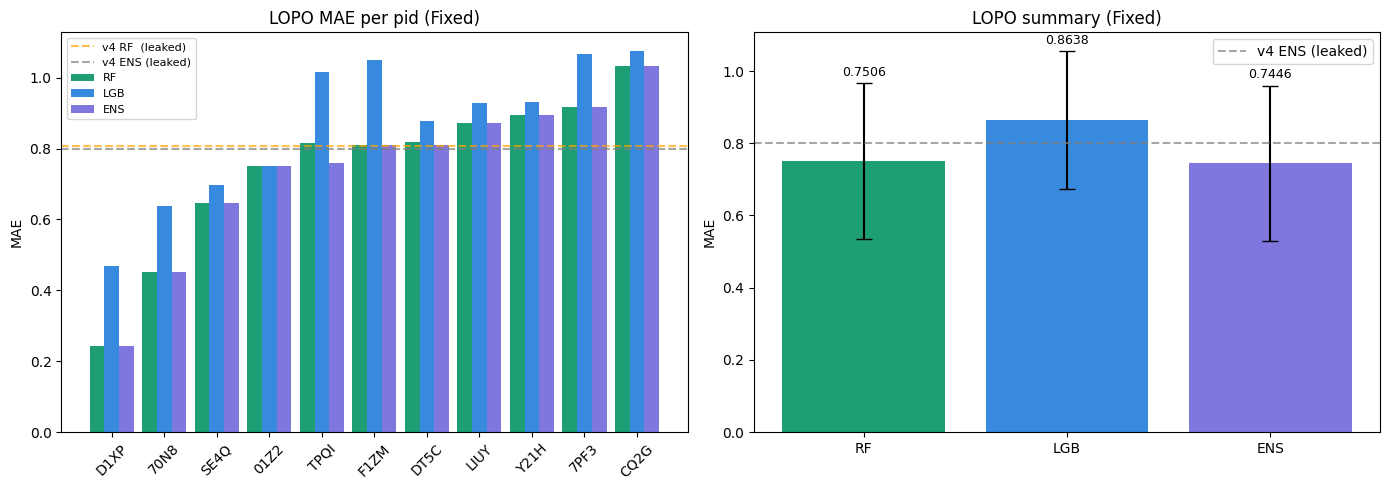

In [12]:
lopo_df = pd.DataFrame(lopo_pid_results).sort_values('ens')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(lopo_df)); w = 0.28

axes[0].bar(x - w, lopo_df['rf'],  w, label='RF',  color='#1D9E75')
axes[0].bar(x,     lopo_df['lgb'], w, label='LGB', color='#378ADD')
axes[0].bar(x + w, lopo_df['ens'], w, label='ENS', color='#7F77DD')
axes[0].axhline(0.8082, color='orange', ls='--', alpha=0.7, label='v4 RF  (leaked)')
axes[0].axhline(0.8002, color='gray',   ls='--', alpha=0.7, label='v4 ENS (leaked)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(lopo_df['pid'], rotation=45)
axes[0].set_ylabel('MAE')
axes[0].set_title('LOPO MAE per pid (Fixed)')
axes[0].legend(fontsize=8)

names = ['RF', 'LGB', 'ENS']
means = [np.mean(lopo_maes[k]) for k in ['rf','lgb','ens']]
stds  = [np.std(lopo_maes[k])  for k in ['rf','lgb','ens']]
axes[1].bar(names, means, yerr=stds,
            color=['#1D9E75','#378ADD','#7F77DD'], capsize=6)
axes[1].axhline(0.8002, color='gray', ls='--', alpha=0.7, label='v4 ENS (leaked)')
axes[1].set_ylabel('MAE')
axes[1].set_title('LOPO summary (Fixed)')
axes[1].legend()
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 0.02, f'{m:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('lopo_fixed.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Final Model Training

Same pipeline as inside LOPO, but fitted on the **full training set**.  
Feature selection here is fine — we are not evaluating on training data.


Training final model on full training set...

  Class 1.0 (55): 3 outliers removed
  Class 2.0 (430): 31 outliers removed
  Class 3.0 (554): 39 outliers removed
  Class 4.0 (345): 25 outliers removed
  Class 5.0 (72): 4 outliers removed
Kept: 1354 / 1456

Selected 66 features for final model

Top 20 features (after count features removed):
      feature  importance
     ibi_skew    0.055878
      eda_min    0.030745
  hr_baseline    0.029172
 eda_q75_lag2    0.025058
temp_baseline    0.023243
      ibi_q25    0.020871
 acc_max_lag1    0.020777
 eda_baseline    0.019115
     temp_min    0.017981
    ibi_pnn50    0.017274
      acc_std    0.016904
 eda_min_lag1    0.016744
temp_min_lag1    0.016700
    temp_mean    0.015896
 eda_q75_lag1    0.014740
   temp_range    0.013706
 acc_baseline    0.013009
      acc_iqr    0.013005
 eda_min_lag2    0.012572
temp_min_lag2    0.012231


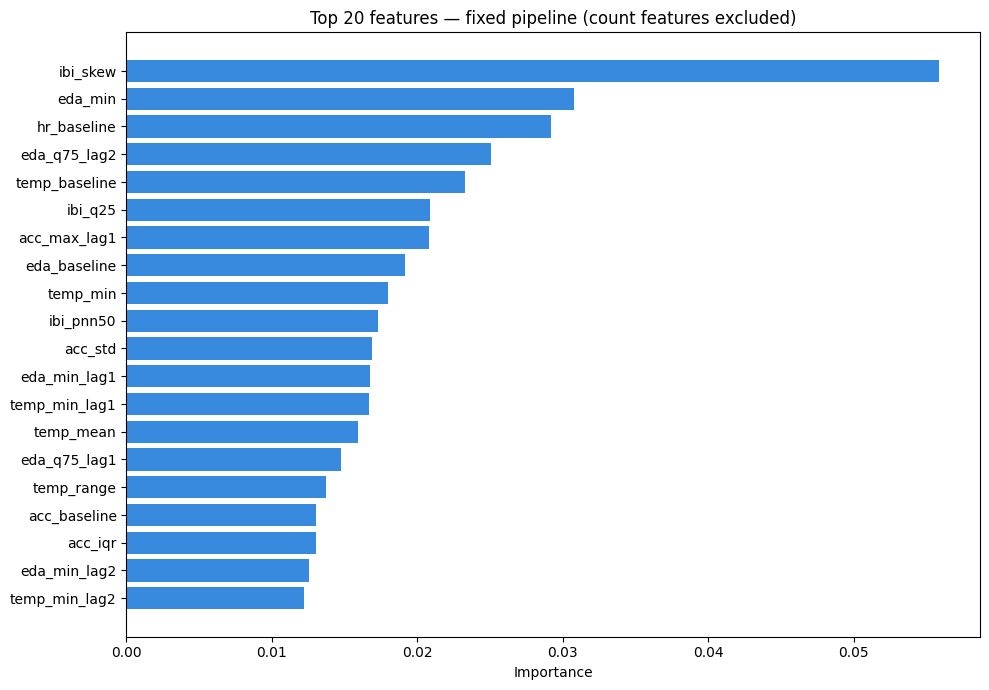

In [13]:
print('Training final model on full training set...\n')

# Step A: Outlier removal on full training set
X_all_raw = train_base[feat_cols_base].values
y_all_raw = train_base['arousal'].values.astype(float)

outlier_mask_final = np.zeros(len(train_base), dtype=bool)
for cls in np.unique(y_all_raw):
    idx           = np.where(y_all_raw == cls)[0]
    contamination = 0.05 if len(idx) < 100 else 0.07
    iso           = IsolationForest(n_estimators=100,
                                    contamination=contamination,
                                    random_state=42)
    preds         = iso.fit_predict(X_all_raw[idx])
    n_out         = np.sum(preds == -1)
    print(f'  Class {cls} ({len(idx)}): {n_out} outliers removed')
    outlier_mask_final[idx[preds == -1]] = True

train_clean = train_base[~outlier_mask_final].copy().reset_index(drop=True)
print(f'Kept: {len(train_clean)} / {len(train_base)}\n')

# Step B: Per-pid normalisation on full clean training set
norm_cols_final = [c for c in feat_cols_base if not c.endswith('_missing')]

train_norm_final = train_clean.copy()
for pid in train_norm_final['pid'].unique():
    m   = train_norm_final['pid'] == pid
    sub = train_norm_final.loc[m, norm_cols_final]
    mu  = sub.mean()
    sig = sub.std().replace(0, np.nan)
    train_norm_final.loc[m, norm_cols_final] = (sub - mu) / sig
train_norm_final[norm_cols_final] = train_norm_final[norm_cols_final].fillna(0)

# Step C: Feature selection on full training set
X_sel_f = train_norm_final[feat_cols_base].values
y_sel_f = train_norm_final['arousal'].values.astype(float)

rf_sel_f = RandomForestRegressor(n_estimators=200, max_depth=8,
                                  random_state=42, n_jobs=-1)
rf_sel_f.fit(X_sel_f, y_sel_f)

imp_f      = pd.Series(rf_sel_f.feature_importances_, index=feat_cols_base)
final_top  = imp_f.nlargest(N_KEEP).index.tolist()
for ind in indicator_cols:
    if ind not in final_top and ind in feat_cols_base:
        final_top.append(ind)

print(f'Selected {len(final_top)} features for final model')

imp_df = pd.DataFrame({
    'feature':    feat_cols_base,
    'importance': rf_sel_f.feature_importances_,
}).sort_values('importance', ascending=False)

print('\nTop 20 features (after count features removed):')
print(imp_df.head(20).to_string(index=False))

# Plot top-20
top20 = imp_df.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#378ADD')
ax.set_title('Top 20 features — fixed pipeline (count features excluded)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('importance_fixed.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# Step D: Normalise test set using training global mean/std
mu_train  = train_clean[norm_cols_final].mean()
sig_train = train_clean[norm_cols_final].std().replace(0, np.nan)

test_norm_final = test_df.copy()
test_norm_final[norm_cols_final] = (test_df[norm_cols_final] - mu_train) / sig_train
test_norm_final[norm_cols_final] = test_norm_final[norm_cols_final].fillna(0)

# Step E: ADASYN + class weights on full clean training set
X_train_f = train_norm_final[final_top].values
y_train_f = train_norm_final['arousal'].values.astype(float)

unique_f, counts_f = np.unique(y_train_f, return_counts=True)
print('Before resampling:')
for u, c in zip(unique_f, counts_f): print(f'  Class {u}: {c}')

target_f = {int(cls): max(int(cnt), 150) for cls, cnt in zip(unique_f, counts_f)}
safe_k_f = max(1, min(4, int(min(counts_f)) - 1))
try:
    res_f = ADASYN(sampling_strategy=target_f,
                   n_neighbors=safe_k_f, random_state=42)
    X_res_f, y_res_f = res_f.fit_resample(X_train_f, y_train_f)
    print('ADASYN succeeded.')
except Exception as e:
    print(f'ADASYN failed ({e}), using SMOTE...')
    res_f = SMOTE(sampling_strategy=target_f,
                  k_neighbors=safe_k_f, random_state=42)
    X_res_f, y_res_f = res_f.fit_resample(X_train_f, y_train_f)

print('After resampling:')
for u, c in zip(*np.unique(y_res_f, return_counts=True)): print(f'  Class {u}: {c}')

cls_counts_f = dict(zip(*np.unique(y_res_f, return_counts=True)))
total_f      = len(y_res_f)
cw_f = {cls: total_f / (len(cls_counts_f) * cnt) for cls, cnt in cls_counts_f.items()}
cw_f[1] = cw_f.get(1, 1.0) * 2.0
cw_f[5] = cw_f.get(5, 1.0) * 2.0
sw_f = np.array([cw_f[y] for y in y_res_f])

print('\nClass weights:')
for k, v in sorted(cw_f.items()): print(f'  Class {k}: {v:.3f}')

Before resampling:
  Class 1.0: 52
  Class 2.0: 399
  Class 3.0: 515
  Class 4.0: 320
  Class 5.0: 68
ADASYN succeeded.
After resampling:
  Class 1.0: 163
  Class 2.0: 399
  Class 3.0: 515
  Class 4.0: 320
  Class 5.0: 146

Class weights:
  Class 1.0: 3.787
  Class 2.0: 0.773
  Class 3.0: 0.599
  Class 4.0: 0.964
  Class 5.0: 4.227


In [15]:
# Step F: Train final RF + LGB
print('\nFitting final RF...')
rf_final = RandomForestRegressor(**rf_params)
rf_final.fit(X_res_f, y_res_f.astype(float), sample_weight=sw_f)
print('  RF done.')

print('Fitting final LGB...')
lgb_final = lgb.LGBMRegressor(**lgb_params)
lgb_final.fit(X_res_f, y_res_f.astype(float), sample_weight=sw_f)
print('  LGB done.')

# Ensemble weights from LOPO (inverse MAE)
inv    = np.array([1 / np.mean(lopo_maes['rf']), 1 / np.mean(lopo_maes['lgb'])])
w_rf_f, w_lgb_f = inv / inv.sum()
print(f'\nFinal ensemble weights: RF={w_rf_f:.3f}, LGB={w_lgb_f:.3f}')

# Sanity check on training data
p_train_check = ordinal_clip(
    w_rf_f  * rf_final.predict(X_train_f) +
    w_lgb_f * lgb_final.predict(X_train_f))
print(f'Train MAE (in-sample, for reference only): '
      f'{mean_absolute_error(y_train_f, p_train_check):.4f}')
print(f'Honest generalisation estimate (LOPO ENS): {np.mean(lopo_maes["ens"]):.4f}')


Fitting final RF...
  RF done.
Fitting final LGB...
  LGB done.

Final ensemble weights: RF=0.535, LGB=0.465
Train MAE (in-sample, for reference only): 0.3124
Honest generalisation estimate (LOPO ENS): 0.7446


## 9. Test Predictions + Rank Calibration

In [16]:
X_test_f = test_norm_final[final_top].values

raw_rf_f  = rf_final.predict(X_test_f)
raw_lgb_f = lgb_final.predict(X_test_f)
raw_ens_f = w_rf_f * raw_rf_f + w_lgb_f * raw_lgb_f

# Rank-based calibration: map test quantiles → train quantiles
train_y_float = train_norm_final['arousal'].values.astype(float)
train_q = np.percentile(train_y_float,  np.linspace(0, 100, 1000))
pred_q  = np.percentile(raw_ens_f,      np.linspace(0, 100, 1000))
calib_fn = interp1d(pred_q, train_q,
                     bounds_error=False,
                     fill_value=(train_q[0], train_q[-1]))

pred_classes_f = ordinal_clip(calib_fn(raw_ens_f))

print('Prediction distribution (after calibration):')
for cls in range(1, 6):
    cnt       = (pred_classes_f == cls).sum()
    pct       = cnt / len(pred_classes_f) * 100
    train_pct = (train_labels['arousal'] == cls).mean() * 100
    print(f'  Class {cls}: {cnt:4d} ({pct:.1f}%)  |  Train {train_pct:.1f}%  '
          f'|  Δ={pct - train_pct:+.1f}%')

Prediction distribution (after calibration):
  Class 1:   58 (3.9%)  |  Train 3.8%  |  Δ=+0.1%
  Class 2:  440 (29.4%)  |  Train 29.5%  |  Δ=-0.1%
  Class 3:  569 (38.0%)  |  Train 38.0%  |  Δ=-0.0%
  Class 4:  354 (23.7%)  |  Train 23.7%  |  Δ=-0.0%
  Class 5:   75 (5.0%)  |  Train 4.9%  |  Δ=+0.1%


## 10. Generate Submission

In [17]:
submission = pd.DataFrame({
    'id':      test_labels['id'].values,
    'arousal': pred_classes_f,
})

assert len(submission) == len(test_labels)
assert submission['arousal'].between(1, 5).all()
assert (submission['id'] == test_labels['id']).all()

print('Final distribution:')
print(submission['arousal'].value_counts().sort_index())

submission.to_csv('submission_fixed.csv', index=False)
print('\nSaved: submission_fixed.csv')

Final distribution:
arousal
1     58
2    440
3    569
4    354
5     75
Name: count, dtype: int64

Saved: submission_fixed.csv


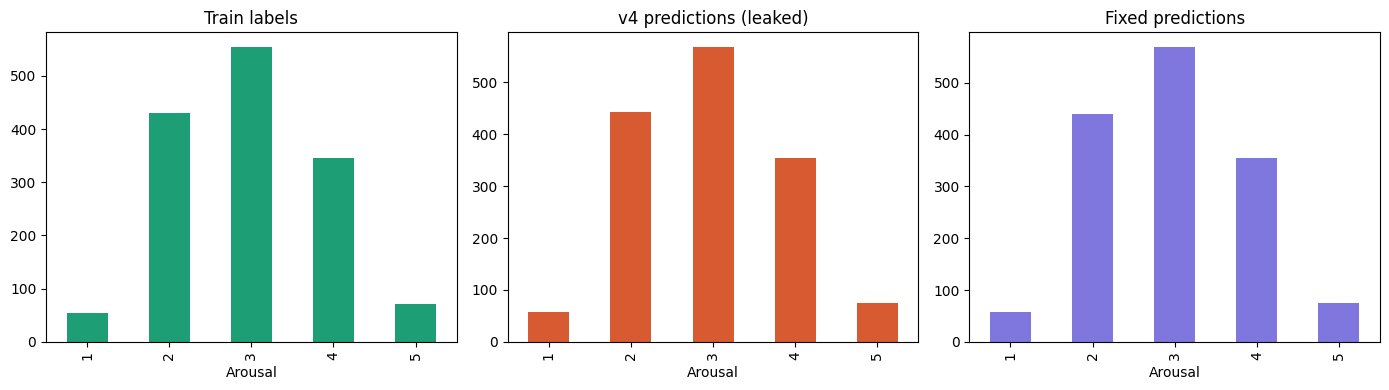


=== Summary ===
v3  LB score:       0.21437
v4  LOPO ENS:       0.8002  (leaked — optimistic)
Fixed LOPO ENS:     0.7446  (honest estimate)
Fixed LOPO RF:      0.7506

If fixed LOPO ≈ v4 LOPO → leaks had little practical impact.
If fixed LOPO >> v4 LOPO → the leaks were masking real overfitting.


In [18]:
# Summary comparison plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

train_labels['arousal'].value_counts().sort_index().plot.bar(
    ax=axes[0], color='#1D9E75')
axes[0].set_title('Train labels'); axes[0].set_xlabel('Arousal')

# Approximate v4 test distribution for comparison
pd.Series({1:57, 2:442, 3:568, 4:355, 5:74}).plot.bar(
    ax=axes[1], color='#D85A30')
axes[1].set_title('v4 predictions (leaked)'); axes[1].set_xlabel('Arousal')

submission['arousal'].value_counts().sort_index().plot.bar(
    ax=axes[2], color='#7F77DD')
axes[2].set_title('Fixed predictions'); axes[2].set_xlabel('Arousal')

plt.tight_layout()
plt.savefig('v4_vs_fixed.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n=== Summary ===')
print(f'v3  LB score:       0.21437')
print(f'v4  LOPO ENS:       0.8002  (leaked — optimistic)')
print(f'Fixed LOPO ENS:     {np.mean(lopo_maes["ens"]):.4f}  (honest estimate)')
print(f'Fixed LOPO RF:      {np.mean(lopo_maes["rf"]):.4f}')
print()
print('If fixed LOPO ≈ v4 LOPO → leaks had little practical impact.')
print('If fixed LOPO >> v4 LOPO → the leaks were masking real overfitting.')